# Exercise 2: Linear regression in 1D

The required part follows the subject order: generated data, fitted line, predictions, and MSE. After that, the notebook compares the same task under two noise levels.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression

plt.style.use("seaborn-v0_8-whitegrid")

def compute_mse(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    return np.mean((y_true - y_pred) ** 2)

def fit_1d_regression(noise):
    X, y, coef = make_regression(
        n_samples=100,
        n_features=1,
        n_informative=1,
        noise=noise,
        coef=True,
        random_state=0,
        bias=100.0,
    )
    model = LinearRegression().fit(X, y)
    y_pred = model.predict(X)
    return X, y, coef, model, y_pred

def plot_regression(ax, X, y, model, title):
    x_values = X.reshape(-1)
    order = np.argsort(x_values)
    ax.scatter(x_values, y, s=30, color="#2a9d8f", alpha=0.75, label="Data")
    ax.plot(x_values[order], model.predict(X)[order], color="#e76f51", linewidth=2.5, label="Fitted line")
    ax.set(title=title, xlabel="x", ylabel="y")
    ax.legend()


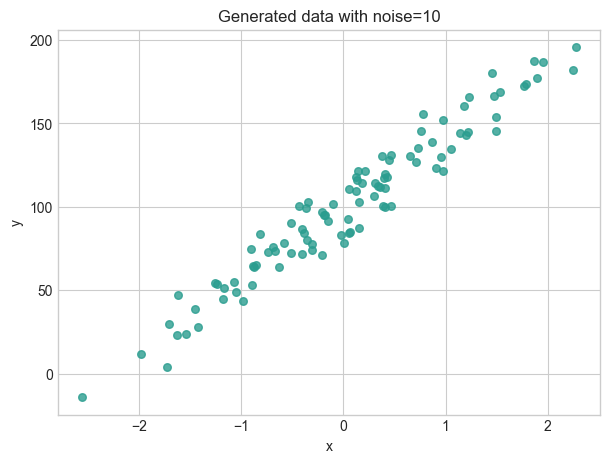

In [2]:
X, y, true_coef, model, y_pred = fit_1d_regression(noise=10)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(X.reshape(-1), y, s=30, color="#2a9d8f", alpha=0.8)
ax.set(title="Generated data with noise=10", xlabel="x", ylabel="y")
plt.show()


In [3]:
print(f"y = {model.coef_[0]} * x + {model.intercept_}")


y = 42.619430291366946 * x + 99.18581817296929


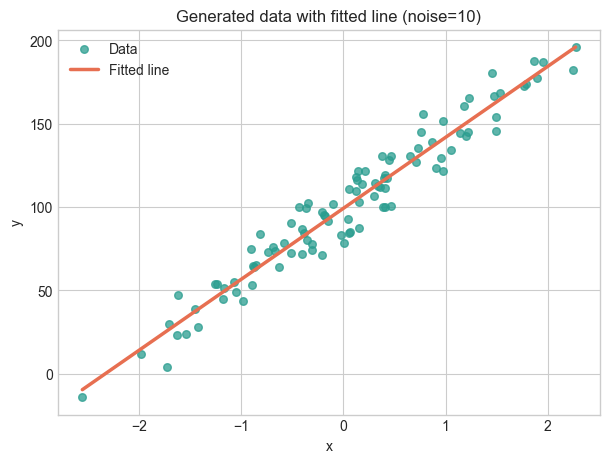

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
plot_regression(ax, X, y, model, "Generated data with fitted line (noise=10)")
plt.show()


In [5]:
print(repr(y_pred[:10]))
print(compute_mse(y, y_pred))


array([ 83.86186727, 140.80961751, 116.3333897 ,  64.52998689,
        61.34889539, 118.10301628,  57.5347917 , 117.44107847,
       108.06237908,  85.90762675])
114.17148616819485


The second dataset uses stronger noise. The fitted coefficient stays close to the same trend, while the error grows significantly.


In [6]:
X_noisy, y_noisy, _, model_noisy, y_pred_noisy = fit_1d_regression(noise=50)

print(f"y = {model_noisy.coef_[0]} * x + {model_noisy.intercept_}")
print(repr(y_pred_noisy[:10]))
print(compute_mse(y_noisy, y_pred_noisy))


y = 43.555132033562856 * x + 95.92909086484637
array([ 80.26870544, 138.46673305, 113.45313417,  60.51239719,
        57.26146541, 115.26161257,  53.36362377, 114.58514204,
       105.00053503,  82.35937919])
2854.2871542048706


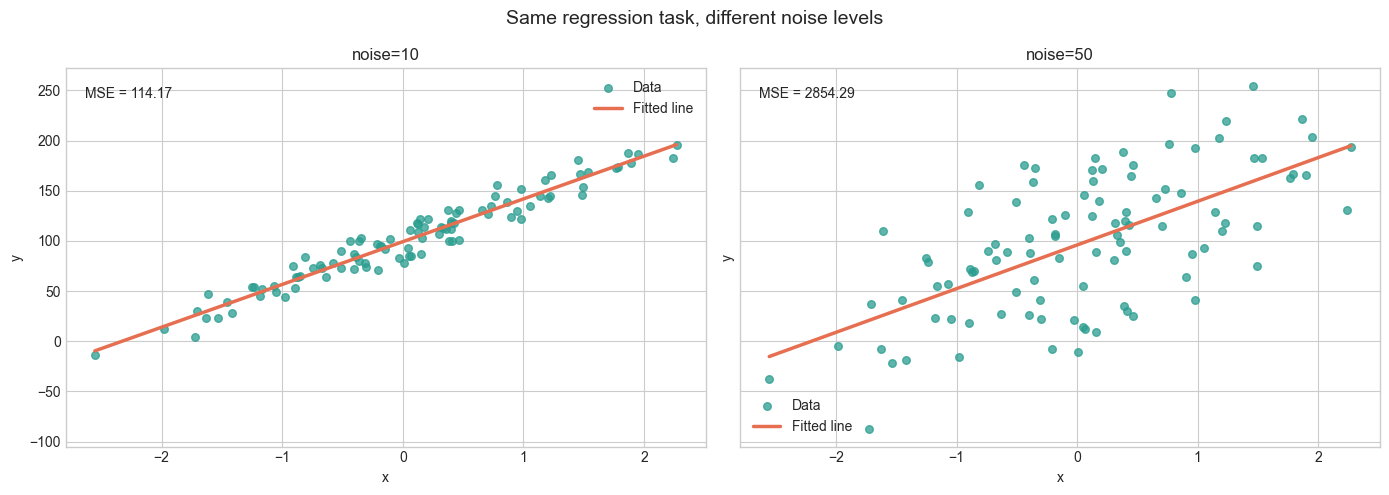

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

plot_regression(axes[0], X, y, model, "noise=10")
axes[0].text(0.03, 0.95, f"MSE = {compute_mse(y, y_pred):.2f}", transform=axes[0].transAxes, va="top")

plot_regression(axes[1], X_noisy, y_noisy, model_noisy, "noise=50")
axes[1].text(0.03, 0.95, f"MSE = {compute_mse(y_noisy, y_pred_noisy):.2f}", transform=axes[1].transAxes, va="top")

fig.suptitle("Same regression task, different noise levels", fontsize=14)
fig.tight_layout()
plt.show()
